## 1. Data Loading & Preprocessing
Loading the raw text and standardizing the cleaning pipeline.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../processed_for_clustering/imdb_unsup.csv')

# Deterministic cleaning pipeline
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

print("Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)
print(f"Data ready. Shape: {df.shape}")


## 4. Feature Engineering (TF-IDF)

In [6]:
# ============================================================
# Feature Engineering — TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.9, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["clean_text"])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")


TF-IDF matrix shape: (50000, 2000)


## 5. Dimensionality Reduction (Truncated SVD)

In [7]:
RANDOM_STATE = 42
# ============================================================
# Dimensionality Reduction (Truncated SVD — works directly on sparse TF-IDF)
# ============================================================
from sklearn.decomposition import TruncatedSVD

# Use enough components to retain most variance for clustering,
# and a separate 2D projection purely for visualization.
n_components = min(50, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_tfidf)

svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd_2d.fit_transform(X_tfidf)

print(f"Reduced feature matrix for clustering: {X_reduced.shape}")
print(f"Explained variance ratio (first {n_components} components): "
      f"{svd.explained_variance_ratio_.sum():.3f}")


Reduced feature matrix for clustering: (50000, 50)
Explained variance ratio (first 50 components): 0.127


## 6. Gaussian Mixture Model Clustering

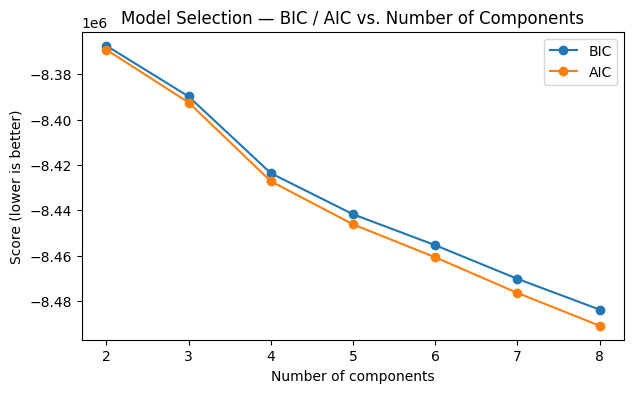

Best number of components by BIC: 8


In [8]:
# ============================================================
# Gaussian Mixture Model — choosing number of components (BIC / AIC)
# ============================================================
from sklearn.mixture import GaussianMixture

n_range = range(2, 9)
bic_scores = []
aic_scores = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type="diag", random_state=RANDOM_STATE)
    gmm.fit(X_reduced)
    bic_scores.append(gmm.bic(X_reduced))
    aic_scores.append(gmm.aic(X_reduced))

plt.figure(figsize=(7, 4))
plt.plot(list(n_range), bic_scores, marker="o", label="BIC")
plt.plot(list(n_range), aic_scores, marker="o", label="AIC")
plt.xlabel("Number of components")
plt.ylabel("Score (lower is better)")
plt.title("Model Selection — BIC / AIC vs. Number of Components")
plt.legend()
plt.show()

best_n = list(n_range)[int(np.argmin(bic_scores))]
print(f"Best number of components by BIC: {best_n}")


In [9]:
# ============================================================
# GMM — comparing covariance types at the chosen number of components
# ============================================================
cov_types = ["full", "tied", "diag", "spherical"]
cov_bic = {}

for cov in cov_types:
    gmm = GaussianMixture(n_components=best_n, covariance_type=cov, random_state=RANDOM_STATE)
    gmm.fit(X_reduced)
    cov_bic[cov] = gmm.bic(X_reduced)

for cov, score in cov_bic.items():
    print(f"{cov:>10}: BIC = {score:.1f}")

best_cov = min(cov_bic, key=cov_bic.get)
print(f"\nBest covariance type by BIC: {best_cov}")


      full: BIC = -9015537.3
      tied: BIC = -8408696.6
      diag: BIC = -8483874.3
 spherical: BIC = -8349935.7

Best covariance type by BIC: full


In [10]:
# ============================================================
# GMM — fit final model
# ============================================================
N_FINAL = best_n            # override manually if desired
COV_FINAL = best_cov         # override manually if desired, e.g. "diag"

gmm_final = GaussianMixture(n_components=N_FINAL, covariance_type=COV_FINAL, random_state=RANDOM_STATE)
df["cluster_gmm"] = gmm_final.fit_predict(X_reduced)
cluster_probs = gmm_final.predict_proba(X_reduced)   # soft assignment probabilities

df["gmm_confidence"] = cluster_probs.max(axis=1)  # how confident the model is in each point's cluster

print(df["cluster_gmm"].value_counts().sort_index())
print(f"\nMean assignment confidence: {df['gmm_confidence'].mean():.3f}")

from sklearn.metrics import silhouette_score
print(f"Silhouette score (hard labels): {silhouette_score(X_reduced, df['cluster_gmm']):.3f}")


cluster_gmm
0    5706
1    6146
2    7688
3    8303
4    4152
5    5626
6    8314
7    4065
Name: count, dtype: int64

Mean assignment confidence: 0.933
Silhouette score (hard labels): -0.029


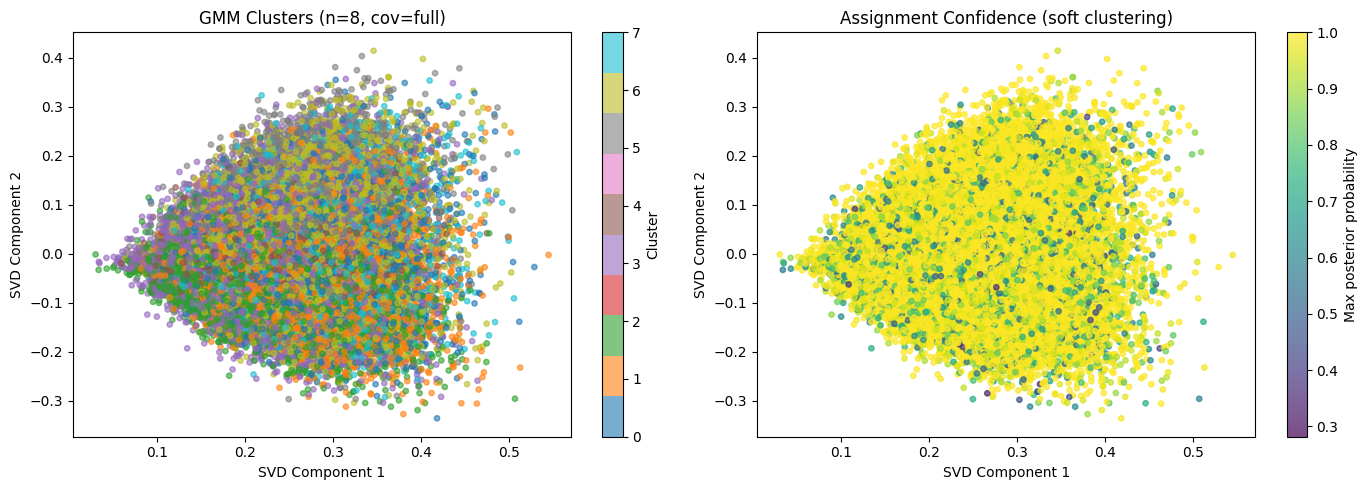

In [11]:
# ============================================================
# GMM — 2D visualization (hard clusters + assignment confidence)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster_gmm"], cmap="tab10", alpha=0.6, s=15)
axes[0].set_title(f"GMM Clusters (n={N_FINAL}, cov={COV_FINAL})")
axes[0].set_xlabel("SVD Component 1"); axes[0].set_ylabel("SVD Component 2")
plt.colorbar(sc1, ax=axes[0], label="Cluster")

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=df["gmm_confidence"], cmap="viridis", alpha=0.7, s=15)
axes[1].set_title("Assignment Confidence (soft clustering)")
axes[1].set_xlabel("SVD Component 1"); axes[1].set_ylabel("SVD Component 2")
plt.colorbar(sc2, ax=axes[1], label="Max posterior probability")

plt.tight_layout()
plt.show()


## 7. Cluster Interpretation

In [12]:
# ============================================================
# GMM — cluster interpretation (top terms per cluster)
# ============================================================
terms = np.array(tfidf.get_feature_names_out())
means_tfidf_space = gmm_final.means_.dot(svd.components_)

for c in range(N_FINAL):
    top_idx = means_tfidf_space[c].argsort()[::-1][:12]
    print(f"Cluster {c} top terms: {', '.join(terms[top_idx])}")

# Low-confidence points are the "boundary" reviews the model is unsure about —
# often the most interesting ones to inspect manually.
uncertain = df.sort_values("gmm_confidence").head(5)
print("\nMost uncertain (boundary) reviews:")
for _, row in uncertain.iterrows():
    print(f"  [{row['gmm_confidence']:.2f}] {row[TEXT_COLUMN][:100]}...")

if LABEL_COLUMN is not None and LABEL_COLUMN in df.columns:
    from sklearn.metrics import adjusted_rand_score
    ari = adjusted_rand_score(df[LABEL_COLUMN], df["cluster_gmm"])
    print(f"\nAdjusted Rand Index vs true label (sanity check only): {ari:.3f}")


Cluster 0 top terms: movie, film, book, one, story, original, like, first, good, character, series, time
Cluster 1 top terms: film, movie, one, horror, character, scene, story, like, good, great, get, woman
Cluster 2 top terms: film, movie, one, life, love, story, woman, man, time, like, people, war
Cluster 3 top terms: movie, film, one, like, character, good, time, would, story, see, scene, get
Cluster 4 top terms: show, episode, series, like, one, character, movie, watch, would, funny, get, time
Cluster 5 top terms: movie, film, bad, one, horror, ever, acting, worst, like, seen, good, time
Cluster 6 top terms: movie, film, great, one, funny, like, good, really, comedy, time, see, love
Cluster 7 top terms: movie, film, game, action, one, bad, like, war, good, scene, really, time

Most uncertain (boundary) reviews:
  [0.28] While I prefer Groucho's humor the most amongst all three Marx brothers, it's just not the same with...
  [0.30] Rarely have I seen a film start out slower than MON

## 8. Insights & Discussion

## Insights & Discussion — GMM

*Fill this section in after running on the full unsupervised dataset.*

- Compare the clusters found here to the K-Means clusters — do they roughly
  agree, or does GMM split the data differently? GMM allows elliptical,
  differently-sized clusters, so disagreement is expected if the real
  structure isn't spherical.
- What do the low-confidence (boundary) reviews have in common? These are
  often mixed-sentiment or sarcastic reviews.
- Which covariance type won by BIC, and what does that say about the shape
  of the underlying clusters in the reduced feature space?
- If a label column was available, how did the ARI compare to K-Means's?
- Limitation: GMM assumes clusters are (approximately) Gaussian in the
  reduced space — a strong assumption for TF-IDF/SVD text features, so treat
  cluster boundaries as approximate rather than exact.
